In [1]:
from pathlib import Path
from tqdm import tqdm
tqdm.pandas()
#
import biotite.structure as struc
import biotite.structure.io as strucio
from atomworks.io.utils.visualize import view
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository
Environment variable PDB_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

#### Find differences between backbones with and w/o RFdiffusion refinement

In [3]:
# paths to data
original_path = '/wynton/home/rotation/geanhu/multi-state/data/string-sampling/end-states'
refined_path = '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE-5KPH/pdb'

In [78]:
# store df of all names
data = {
    'name': []
}
for item in Path(original_path).iterdir():
    if str(item).endswith('.pdb'):
        data['name'].append(item.stem)
data = pd.DataFrame(data)
data = data.sort_values(by='name')

In [25]:
# calculate RMSD of original vs rfdiffusion refined
def find_rmsd(name):
    # load structure files
    original_file = f'{original_path}/{name}.pdb'
    if Path(original_file).exists():
        original_struc = strucio.load_structure(
            original_file
        )
    else:
        return None
    refined_file = f'{refined_path}/{name}_0.pdb'
    if Path(refined_file).exists():
        refined_struc = strucio.load_structure(
            refined_file
        )
    else:
        return None

    # superimpose / align
    refined_aligned, transform = struc.superimpose(
        original_struc,
        refined_struc,
        atom_mask=(struc.filter_peptide_backbone(refined_struc))
    )
    strucio.save_structure('./test_align.pdb', refined_aligned)

    # get C_alpha rmsd
    return struc.rmsd(
        original_struc[original_struc.atom_name == "CA"],
        refined_aligned[refined_aligned.atom_name == "CA"]
    )
    
data['rmsd'] = data['name'].progress_apply(
    lambda name: find_rmsd(name)
)

100%|███████████████████████████████████████████████████████| 315/315 [00:09<00:00, 33.45it/s]


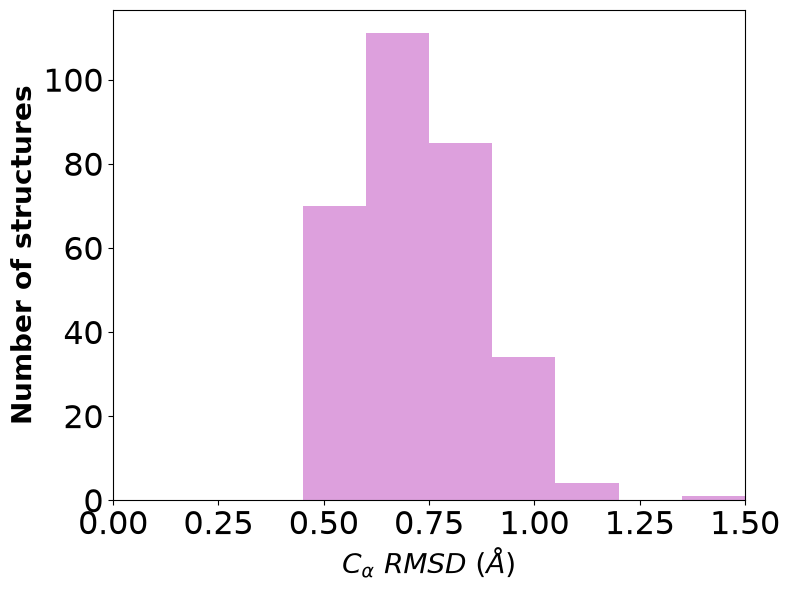

In [38]:
plt.figure(figsize=(8, 6))
#
plt.hist(
    data['rmsd'],
    bins = 10,
    range=(0, 1.5),
    color = 'plum'
)
#
plt.xlabel(r'$C_{\alpha}\ RMSD\ (\AA)$', fontsize=20, fontweight='bold')
plt.ylabel('Number of structures', fontsize=20, fontweight='bold')
plt.tick_params(axis='x', labelsize=23)
plt.tick_params(axis='y', labelsize=23)
plt.xlim(0, 1.5)
#
plt.tight_layout()
plt.show()

In [79]:
def get_angles(
    row
):
    name = row['name']

    # Load original structure
    original = strucio.load_structure(f'{original_path}/{name}.pdb')
    phi_o, psi_o, omega = struc.dihedral_backbone(original) #calculate dihedral angles
    phi_o = np.rad2deg(phi_o)[1:-1] #rad -> deg, truncate nan
    psi_o = np.rad2deg(psi_o)[1:-1]
    
    # Load diffusion refined structure
    refined_pdb = f'{refined_path}/{name}_0.pdb'
    if Path(refined_pdb).exists():
        refined = strucio.load_structure(refined_pdb)
        phi_r, psi_r, omega = struc.dihedral_backbone(refined)
        phi_r = np.rad2deg(phi_r)[1:-1]
        psi_r =  np.rad2deg(psi_r)[1:-1]
    else:
        return None
    
    return (phi_o, psi_o, phi_r, psi_r)

data[["phi_o", "psi_o", "phi_r", "psi_r"]] = data.progress_apply( #type:ignore
    lambda row: get_angles(row),
    axis = 1,
    result_type = "expand"
) #type: ignore

100%|██████████████████████████████| 315/315 [00:04<00:00, 76.31it/s]


In [80]:
# calculate difference in dihedral angles
# + 180 to shift [-180, 180] -> [0, 360] change
# % 360 to get smallest rotation angle
# - 180 to shift back into [-180, 180]
data['phi_delta'] = (data['phi_o'] - data['phi_r'] + 180) % 360 - 180
data['psi_delta'] = (data['psi_o'] - data['psi_r'] + 180) % 360 - 180

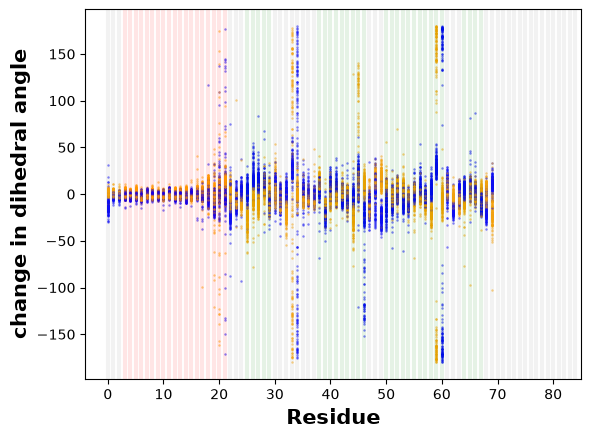

In [34]:
plt.figure()

structure_name = '5KPH'
for name in data['name']:
    if structure_name in name.split('/')[-1]:
        #get dihedral angles
        '''
        original = strucio.load_structure(f'{original_path}/{name}.pdb')
        phi_o, psi_o, omega = struc.dihedral_backbone(original)
        phi_o = np.rad2deg(phi_o)[1:-1]
        psi_o = np.rad2deg(psi_o)[1:-1]
        #
        refined_pdb = f'{refined_path}/{name}_0.pdb'
        if Path(refined_pdb).exists():
            refined = strucio.load_structure(refined_pdb)
            phi_r, psi_r, omega = struc.dihedral_backbone(refined)
            phi_r = np.rad2deg(phi_r)[1:-1]
            psi_r =  np.rad2deg(psi_r)[1:-1]
        else:
            continue
        '''
        phi_o = data[data['name'] == name]['phi_o'].values[0]
        phi_r = data[data['name'] == name]['phi_r'].values[0]
        psi_o = data[data['name'] == name]['psi_o'].values[0]
        psi_r = data[data['name'] == name]['psi_r'].values[0]

        if phi_o is not None:
        
            #phi angle changes
            plt.scatter(
                range(phi_o.size),
                (phi_o - phi_r + 180) % 360 - 180,
                color = 'blue',
                alpha = 0.5,
                linewidth=0,
                s = 3
                #label=r'$\phi$'
            )

            #psi angle changes
            plt.scatter(
                range(len(psi_o)),
                (psi_o - psi_r + 180) % 360 - 180,
                color = 'orange',
                alpha = 0.5,
                linewidth=0,
                s = 3
                #label=r'$\psi$'
            )

#annotate SS
original = strucio.load_structure(f'/wynton/home/rotation/geanhu/multi-state/data/base/{structure_name}.pdb')[0]
original_ss = struc.annotate_sse(original)
original_ss = [index for index, value in enumerate(original_ss) if value == 'c']
for index in original_ss:
    plt.axvline(
        x = index,
        color = 'gray',
        alpha = 0.1,
        lw = 3
    )
#
original_ss = struc.annotate_sse(original)
original_ss = [index for index, value in enumerate(original_ss) if value == 'a']
for index in original_ss:
    plt.axvline(
        x = index,
        color = 'red',
        alpha = 0.1,
        lw = 3
    )
#
original_ss = struc.annotate_sse(original)
original_ss = [index for index, value in enumerate(original_ss) if value == 'b']
for index in original_ss:
    plt.axvline(
        x = index,
        color = 'green',
        alpha = 0.1,
        lw = 3
    )

#axes
plt.ylabel(r'change in dihedral angle', fontsize=15, fontweight='bold')
#plt.ylim(-180, 180)
plt.xlabel('Residue', fontsize=15, fontweight='bold')
plt.show()

In [43]:
data = data.dropna()
data = data[data['name'].str.contains('5KPE')]
np.vstack([arr for arr in data['phi_delta']]).shape

(152, 106)

In [81]:
# Write structure with std dev change
structure_name = '5KPE'

# Get std dev of torsion angle changes
data = data.dropna()
data = data[data['name'].str.contains(structure_name)]
phi_d_std = np.std(np.vstack([arr for arr in data['phi_delta']]), axis=0)
psi_d_std = np.std(np.vstack([arr for arr in data['psi_delta']]), axis=0)
angle_d_std = np.max([phi_d_std, psi_d_std], axis=0) #take max between phi and psi angle change

# Load original structure
original = strucio.load_structure(f'/wynton/home/rotation/geanhu/multi-state/data/base/{structure_name}.pdb', extra_fields=['b_factor'])[0] #type:ignore

# Load, impute 0
atom_values = np.zeros(int(struc.get_residue_count(original)))
atom_values[:len(angle_d_std)] = angle_d_std

# Annotate
original.b_factor = [
    atom_values[res_id - 1] #since res # is 1-indexed
    for res_id in original.res_id
]

# save
strucio.save_structure(f'/wynton/home/rotation/geanhu/multi-state/data/misc/{structure_name}_angle-delta-std.pdb', original)

/wynton/home/rotation/geanhu/.conda/envs/analysis/lib/python3.14/site-packages/biotite/structure/io/pdb/file.py:615: DeprecationWarning: The chararray class is deprecated and will be removed in a future release. Use an ndarray with a string or bytes dtype instead.
  record = np.char.array(np.where(array.hetero, "HETATM", "ATOM"))


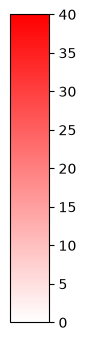

In [86]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# colorbar for pymol structure
norm = mcolors.Normalize(vmin=0, vmax=40)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "red"]
)

fig, ax = plt.subplots(figsize=(0.5, 4))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(
    sm,
    cax = ax,
    orientation="vertical"
)
plt.show()

#### Effect of increasing diffuser.T

In [161]:
data = {
    't': [0, 50, 100, 150, 200],
    'paths': [
        '/wynton/home/rotation/geanhu/multi-state/data/string-sampling/end-states/5KPE_8_8_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE-5KPH/pdb/5KPE_8_8_0_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE_higher-T/100_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE_higher-T/150_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE_higher-T/200_0.pdb'
    ]
}
data = pd.DataFrame(data)

In [67]:
def find_rmsd(name):
    # load structure files
    original_file = data.loc[0, 'paths']
    if Path(original_file).exists():
        original_struc = strucio.load_structure(
            original_file
        )
    else:
        return None
    refined_file = name
    if Path(refined_file).exists():
        refined_struc = strucio.load_structure(
            refined_file
        )
    else:
        return None

    # superimpose / align
    refined_aligned, transform = struc.superimpose(
        original_struc,
        refined_struc,
        atom_mask=(struc.filter_peptide_backbone(refined_struc))
    )

    # get C_alpha rmsd
    rmsd = struc.rmsd(
        original_struc[original_struc.atom_name == "CA"],
        refined_aligned[refined_aligned.atom_name == "CA"]
    )
    return rmsd

data['rmsd'] = data['paths'].apply(
    lambda name: find_rmsd(name)
)

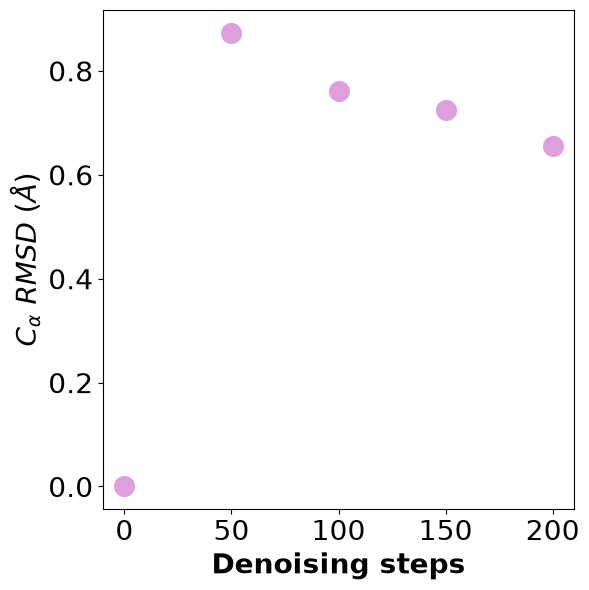

In [76]:
plt.figure(figsize=(6, 6))
#
plt.scatter(
    data['t'].astype(int),
    data['rmsd'],
    color = 'plum',
    s=200
)
#
plt.xlabel('Denoising steps', fontsize=20, fontweight='bold')
plt.ylabel(r'$C_{\alpha}\ RMSD\ (\AA)$', fontsize=20, fontweight='bold')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
#
plt.tight_layout()
plt.show()

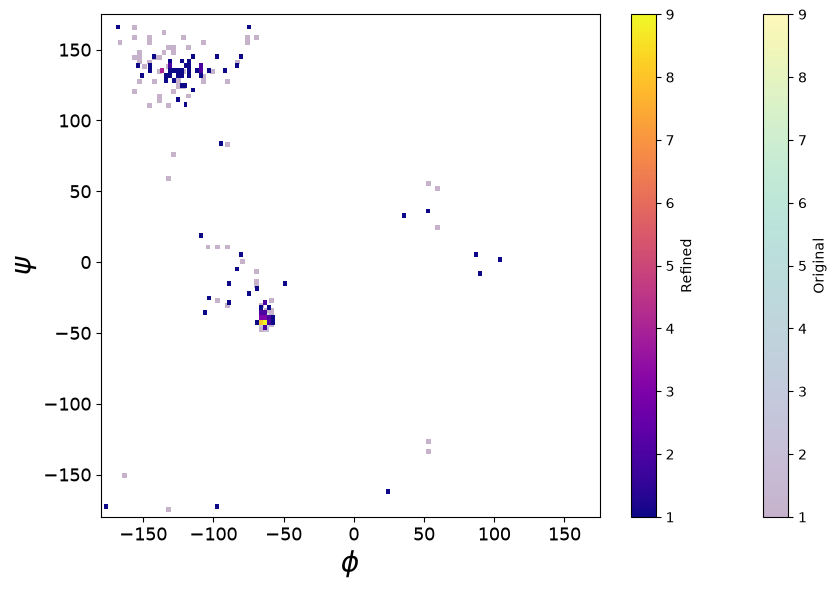

In [162]:
# Plot Ramachandran plots
plt.figure(figsize=(9,6))
#
original = strucio.load_structure(data.loc[0, 'paths'])
phi_o, psi_o, omega = struc.dihedral_backbone(original)
phi_o = np.rad2deg(phi_o)[1:-1]
psi_o = np.rad2deg(psi_o)[1:-1]
_, _, _, im = plt.hist2d(
    phi_o,
    psi_o,
    bins=(100,100),
    cmap='viridis',
    alpha = 0.3,
    cmin=1
)
plt.colorbar(im, label='Original')
#
refined = strucio.load_structure(data.loc[1, 'paths'])
phi_r, psi_r, omega = struc.dihedral_backbone(refined)
phi_r = np.rad2deg(phi_r)[1:-1]
psi_r =  np.rad2deg(psi_r)[1:-1]
_, _, _, im2 = plt.hist2d(
    phi_r,
    psi_r,
    bins=(100,100),
    cmap='plasma',
    alpha = 1,
    cmin=1
)
plt.colorbar(im2, label='Refined')
#
plt.xlim(-180, 175)
plt.xlabel(r'$\phi$', fontsize=20, fontweight='bold')
plt.ylabel(r'$\psi$', fontsize=20, fontweight='bold')
plt.ylim(-180, 175)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()